# Breakouts intradía en SPX500 — ¿hay edge?

Aplicamos la misma disciplina DSR a datos de **1 minuto** de FutureSharks
(Oanda `SPX500_USD`, 2005–2020): **discovery** (< 2017) vs **OOS 2017+ sellado**,
coste de transacción explícito, y **sin torneo de parámetros**.

Pregunta: ¿el SPX "sigue" sus rupturas intradía lo suficiente para ganar dinero?

> El notebook narra el proceso e importa la lógica ya testeada de
> `src/alpha_selection/intraday`.

## 0. Setup

In [1]:
import sys, subprocess, warnings, time
from pathlib import Path
sys.path.insert(0, "src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

from alpha_selection.intraday.loader import build_rth_cache, load_rth_cache, load_raw
from alpha_selection.intraday.breakouts import (
    opening_range_breakouts, prior_day_breakouts, session_features,
    evaluate_events, stats_by_year,
)

OOS_START = pd.Timestamp("2017-01-01")   # bloque protegido, sellado
COST_PTS  = 1.0                          # coste round-trip en puntos de índice
# Paleta colorblind-safe.
C_POS, C_NEG, C_A, C_B = "#2166ac", "#d6604d", "#2166ac", "#f4a582"
CACHE = "data/spx_rth.parquet"
print("Setup OK")

Setup OK


## 1. Descarga de datos (FutureSharks)

Clonado disperso de solo `SPX500_USD` (no todo el repo). ~193 MB. `data/` está en
`.gitignore`, así que los datos no se versionan.

In [2]:
SPX_DIR = Path("data/fsdata/pyfinancialdata/data/currencies/oanda/SPX500_USD")
if not SPX_DIR.exists():
    Path("data").mkdir(exist_ok=True)
    subprocess.run(["git","clone","--no-checkout","--depth","1","--filter=blob:none",
                    "https://github.com/FutureSharks/financial-data.git","data/fsdata"], check=True)
    subprocess.run(["git","-C","data/fsdata","sparse-checkout","init","--cone"], check=True)
    subprocess.run(["git","-C","data/fsdata","sparse-checkout","set",
                    "pyfinancialdata/data/currencies/oanda/SPX500_USD"], check=True)
    subprocess.run(["git","-C","data/fsdata","checkout"], check=True)
print("SPX500_USD presente:", SPX_DIR.exists())
sorted(p.name for p in SPX_DIR.glob("*"))[:6]

SPX500_USD presente: True


['2005', '2006', '2007', '2008', '2009', '2010']

## 2. Zona horaria y sesión RTH

Los timestamps vienen en **UTC**. Lo verificamos empíricamente: al convertir a
`America/New_York`, la actividad y el rango intradía culminan justo en la apertura
cash (09:30–10:30 ET) y colapsan en el rollover de las 17:00 ET. Por eso la sesión
RTH 09:30–16:00 ET queda bien definida (y el DST se maneja solo al convertir).

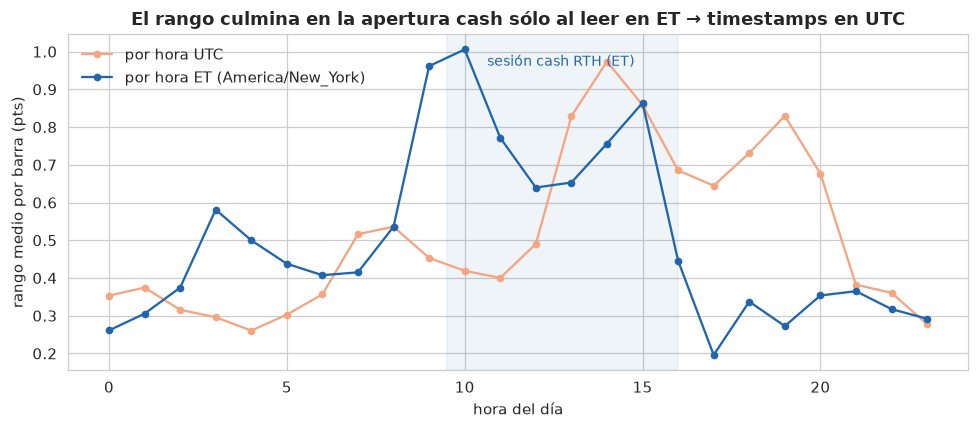

In [3]:
# Evidencia: rango medio por hora en UTC vs en hora del Este (un año).
raw = load_raw(SPX_DIR, years=range(2015, 2016))
raw["rng"] = raw["high"] - raw["low"]
utc_hour = raw["time"].dt.tz_convert("UTC").dt.hour
et_hour  = raw["time"].dt.hour  # load_raw ya devuelve America/New_York
g_utc = raw.groupby(utc_hour)["rng"].mean()
g_et  = raw.groupby(et_hour)["rng"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(g_utc.index, g_utc.values, "-o", ms=4, color=C_B, label="por hora UTC")
ax.plot(g_et.index,  g_et.values,  "-o", ms=4, color=C_A, label="por hora ET (America/New_York)")
ax.axvspan(9.5, 16, color="#2166ac", alpha=0.07)
ax.text(12.7, ax.get_ylim()[1]*0.92, "sesión cash RTH (ET)", color="#2166ac", ha="center", fontsize=9)
ax.set_xlabel("hora del día"); ax.set_ylabel("rango medio por barra (pts)")
ax.set_title("El rango culmina en la apertura cash sólo al leer en ET → timestamps en UTC")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

In [4]:
# Construir (o cargar) la caché RTH minuto a minuto.
if not Path(CACHE).exists():
    t = time.time()
    rth = build_rth_cache(SPX_DIR, CACHE)
    print(f"caché construida en {time.time()-t:.1f}s")
else:
    rth = load_rth_cache(CACHE)

disc = rth[rth["session"] < OOS_START]
n_oos = rth[rth["session"] >= OOS_START]["session"].nunique()
print(f"DISCOVERY: {disc['session'].nunique()} sesiones "
      f"({disc['session'].min().date()} -> {disc['session'].max().date()})")
print(f"OOS sellado: {n_oos} sesiones (>= {OOS_START.date()}) — NO se toca aquí")

DISCOVERY: 2920 sesiones (2005-01-03 -> 2016-12-30)
OOS sellado: 741 sesiones (>= 2017-01-01) — NO se toca aquí


## 3. Setups de breakout — construcción sin fuga

Dos setups, un evento por sesión (primer toque):

1. **Opening Range Breakout (ORB)**: rango = high/low de los primeros R minutos;
   primer **cierre** fuera del rango dispara el evento.
2. **Prior-day H/L**: primer cierre por encima del máximo (o por debajo del mínimo)
   RTH de la sesión anterior.

Regla anti-fuga: la **señal** se confirma con el **cierre** de la barra que rompe;
la **entrada** es la **apertura de la barra siguiente**; la **salida** es el cierre
de la sesión (un breakout intradía se liquida antes de la campana).

## 4. Breakout incondicional

`gross` = sin coste; `net(1pt)` = restando 1 punto de índice round-trip.
`follow-through` = fracción en la que un objetivo simétrico se toca antes que el
stop.

In [5]:
def _t(x):
    x = np.asarray(x, float); sd = x.std(ddof=1)
    return x.mean()/(sd/np.sqrt(len(x))) if sd > 0 else np.nan

rows = []
for orm in (15, 30, 60):
    ev = opening_range_breakouts(disc, or_minutes=orm)
    s, sc = evaluate_events(ev, 0.0), evaluate_events(ev, COST_PTS)
    rows.append(dict(setup=f"ORB-{orm}", n=s.n, gross_bps=round(s.mean_ret_bps,2),
                     t_gross=round(s.t_stat,2), hit=round(s.hit_rate,3),
                     follow_through=round(s.follow_through_rate,3),
                     net_bps=round(sc.mean_ret_bps,2), t_net=round(sc.t_stat,2)))
ev_pd = prior_day_breakouts(disc)
s, sc = evaluate_events(ev_pd, 0.0), evaluate_events(ev_pd, COST_PTS)
rows.append(dict(setup="PriorDay-HL", n=s.n, gross_bps=round(s.mean_ret_bps,2),
                 t_gross=round(s.t_stat,2), hit=round(s.hit_rate,3),
                 follow_through=np.nan, net_bps=round(sc.mean_ret_bps,2), t_net=round(sc.t_stat,2)))
pd.DataFrame(rows).set_index("setup")

,n,gross_bps,t_gross,hit,follow_through,net_bps,t_net
setup,,,,,,,
ORB-15,2918,-0.13,-0.08,0.490,0.479,-7.40,-4.32
ORB-30,2903,0.31,0.19,0.486,0.485,-6.96,-4.26
ORB-60,2832,0.02,0.01,0.497,0.506,-7.25,-4.62
PriorDay-HL,2569,-1.14,-0.61,0.496,NaN,-8.41,-4.52


**Lectura:** retorno medio ≈ 0 bps, hit rate ~48–49%, **t ≈ 0** en las tres
ventanas ORB; follow-through ~48–50% (cara o cruz). Insensible a la ventana del
rango (15/30/60) → no es un problema de parametrización. Con 1 punto de coste todo
cae a ~−7 bps (t ≈ −4.3): mecánicamente pierde. **El SPX no sigue sus rupturas
intradía.**

## 5. Cortes condicionales (hipótesis preespecificadas)

El promedio plano puede esconder estructura condicional. Sobre ORB-30 probamos
cortes con sentido económico. El único coherente y con señal: **continuación del
gap** (breakouts en la dirección del gap overnight).

In [6]:
ev = opening_range_breakouts(disc, or_minutes=30).copy()
feat = session_features(disc)
ev = ev.join(feat[["gap", "prior_close"]], on="session")
ev["ret_bps"] = ev["ret_to_close"] * 1e4
ev["aligned"] = (ev["direction"] == np.sign(ev["gap"])).astype(int)

def cut(name, mask):
    g = ev.loc[mask, "ret_bps"]
    return dict(corte=name, n=len(g), mean_bps=round(g.mean(),2),
                hit=round((g>0).mean(),3), t=round(_t(g),2))

cuts = pd.DataFrame([
    cut("dir == signo(gap)  [continuación]", ev["aligned"]==1),
    cut("dir != signo(gap)  [reversión]",   ev["aligned"]==0),
]).set_index("corte")
cuts

,n,mean_bps,hit,t
corte,,,,
dir == signo(gap) [continuación],1412,6.07,0.515,2.70
dir != signo(gap) [reversión],1491,-5.15,0.459,-2.19


## 6. Robustez de la continuación del gap

Antes de creérnoslo: ¿es solo 2008? ¿sobrevive al coste?

In [7]:
al = ev[ev["aligned"]==1].copy()
al["year"] = pd.to_datetime(al["session"]).dt.year
al["net_bps"] = (al["ret_to_close"] - COST_PTS/al["entry"]) * 1e4
no08 = al[al["year"]!=2008]

summary = pd.DataFrame([
    dict(escenario="discovery completo", n=len(al),
         gross_bps=round(al["ret_bps"].mean(),2), t_gross=round(_t(al["ret_bps"]),2),
         net_bps=round(al["net_bps"].mean(),2), t_net=round(_t(al["net_bps"]),2)),
    dict(escenario="EXCLUYENDO 2008", n=len(no08),
         gross_bps=round(no08["ret_bps"].mean(),2), t_gross=round(_t(no08["ret_bps"]),2),
         net_bps=round(no08["net_bps"].mean(),2), t_net=round(_t(no08["net_bps"]),2)),
]).set_index("escenario")
summary

,n,gross_bps,t_gross,net_bps,t_net
escenario,,,,,
discovery completo,1412,6.07,2.70,-1.17,-0.52
EXCLUYENDO 2008,1295,3.09,1.56,-4.05,-2.04


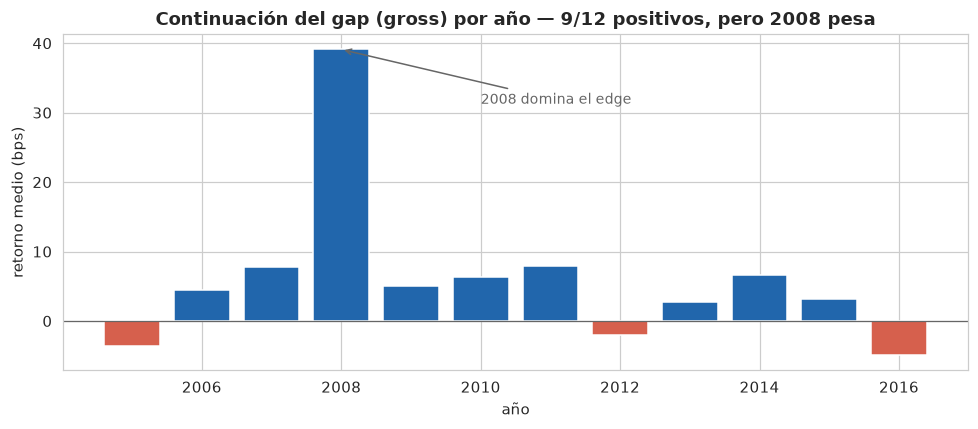

In [8]:
# Gráfica 1: retorno medio por año (gap-aligned, gross). Diverging pos/neg.
by = al.groupby("year")["ret_bps"].mean()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(by.index, by.values, color=[C_POS if v>0 else C_NEG for v in by.values])
ax.axhline(0, color="#666", lw=0.8)
ax.annotate("2008 domina el edge", xy=(2008, by.loc[2008]), xytext=(2010, by.loc[2008]*0.8),
            arrowprops=dict(arrowstyle="->", color="#666"), fontsize=9, color="#666")
ax.set_xlabel("año"); ax.set_ylabel("retorno medio (bps)")
ax.set_title("Continuación del gap (gross) por año — 9/12 positivos, pero 2008 pesa")
plt.tight_layout(); plt.show()

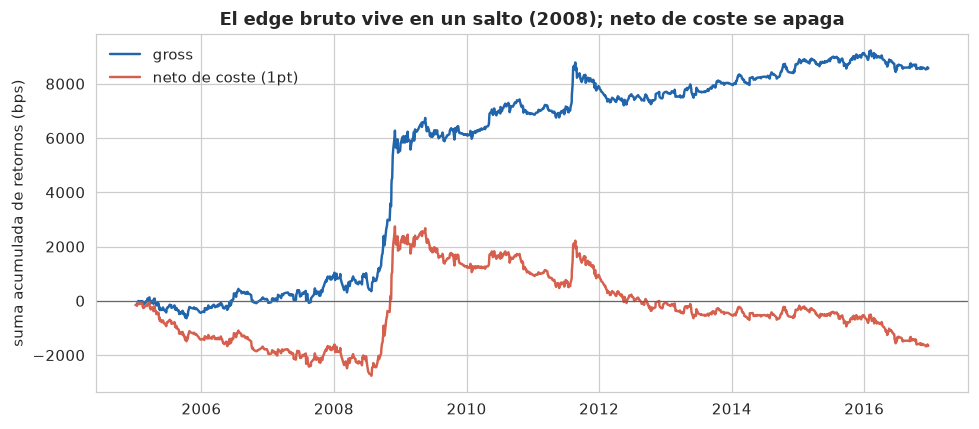

In [9]:
# Gráfica 2: suma acumulada del retorno por evento, gross vs neto de coste.
al_sorted = al.sort_values("session")
cum_gross = (al_sorted["ret_bps"]).cumsum()
cum_net   = (al_sorted["net_bps"]).cumsum()
x = pd.to_datetime(al_sorted["session"]).values
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, cum_gross.values, color=C_A, lw=1.6, label="gross")
ax.plot(x, cum_net.values,   color=C_NEG, lw=1.6, label="neto de coste (1pt)")
ax.axhline(0, color="#666", lw=0.8)
ax.set_ylabel("suma acumulada de retornos (bps)")
ax.set_title("El edge bruto vive en un salto (2008); neto de coste se apaga")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

**Lectura:** gross +6.07 bps (t=2.70) parece prometedor, pero **ex-2008 cae a
t=1.56** (no significativo) y el **neto de coste es negativo** en ambos casos. Casi
la mitad del edge bruto es el año de crisis. La curva acumulada lo confirma: casi
todo el beneficio bruto es un salto en 2008; neto de coste no sube.

## 7. Veredicto — y el OOS sigue sellado

No hay edge de breakout intradía **tradeable** en este SPX a 1 minuto: ni el
incondicional, ni la mejor hipótesis condicional. El promedio plano no escondía un
tesoro; escondía 2008.

**El OOS 2017+ permanece sellado.** No hay candidato que sobreviva discovery, así
que no se gasta el OOS confirmando un negativo — esa es la disciplina: el OOS se
toca una sola vez, para validar un candidato real, no para pescar.

In [10]:
print("OOS status: SELLADO — no evaluado.")
print(f"Sesiones OOS reservadas: {n_oos}  (>= {OOS_START.date()})")
print("Motivo: ningún setup superó discovery neto de coste. No hay candidato que validar.")

OOS status: SELLADO — no evaluado.
Sesiones OOS reservadas: 741  (>= 2017-01-01)
Motivo: ningún setup superó discovery neto de coste. No hay candidato que validar.


## 8. Cómo conecta con el motor de estabilidad

Si se quisiera insistir (no recomendado con estos datos), el camino disciplinado
**no** es probar más ventanas ORB hasta que una brille. Sería:

1. Registrar "continuación del gap" como **una** hipótesis en
   `hypotheses/registry.yaml` (ya anotada como *rejected* con esta evidencia).
2. Derivar sus features (tamaño del gap, hora del breakout, régimen de vol) como
   candidatas atadas a hipótesis.
3. Pasarlas por `stability_select` una vez (ver **Notebook 1**) — criterio:
   estabilidad, no Sharpe.
4. Solo si algo sobrevive estable, gastar el OOS una única vez.

Con lo visto, el paso 3 casi seguro no dejaría nada estable: el efecto depende
demasiado de un régimen (2008) para ser reproducible.

**Limitaciones:** `SPX500_USD` es un CFD de Oanda, no el ETF SPY; el "volumen" es
tick-count del broker (no usado). Coste fijo de 1 pt (en la apertura el spread real
puede ser mayor, lo que solo reforzaría el veredicto). Salida siempre a cierre de
sesión (multiplicar gestiones de salida infla el presupuesto DSR).